# 01 Exploratory Data Analysis

**Goal**: Understand the dataset before touching any model.
- How bad is the class imbalance?
- What does fraud look like vs. legit transactions in the feature space?
- Are there obvious separating features we should know about?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/creditcard.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Class Imbalance

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%
Imbalance ratio: 1 fraud per 577 legit transactions


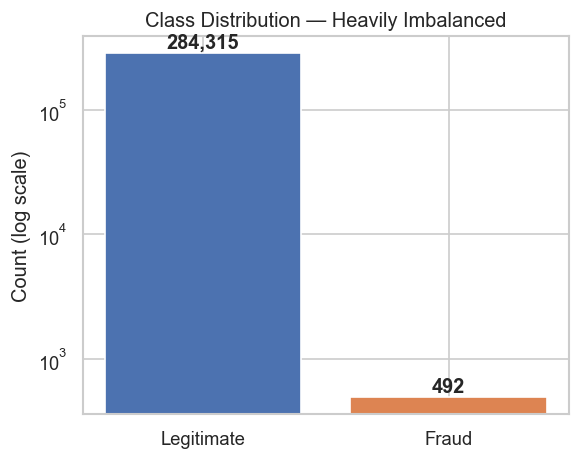

In [2]:
class_counts = df['Class'].value_counts()
print('Class distribution:')
print(class_counts)
print(f'\nFraud rate: {class_counts[1] / len(df) * 100:.3f}%')
print(f'Imbalance ratio: 1 fraud per {int(class_counts[0] / class_counts[1])} legit transactions')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Legitimate', 'Fraud'], class_counts.values, color=['#4C72B0', '#DD8452'])
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.set_title('Class Distribution — Heavily Imbalanced')
for i, v in enumerate(class_counts.values):
    ax.text(i, v * 1.1, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Transaction Amount, Fraud vs. Legit

Are fraudulent transactions larger or smaller?

Amount statistics:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87

Average fraud amount:  $122.21
Average legit amount:  $88.29


C:\Users\User\AppData\Local\Temp\ipykernel_4244\602378948.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


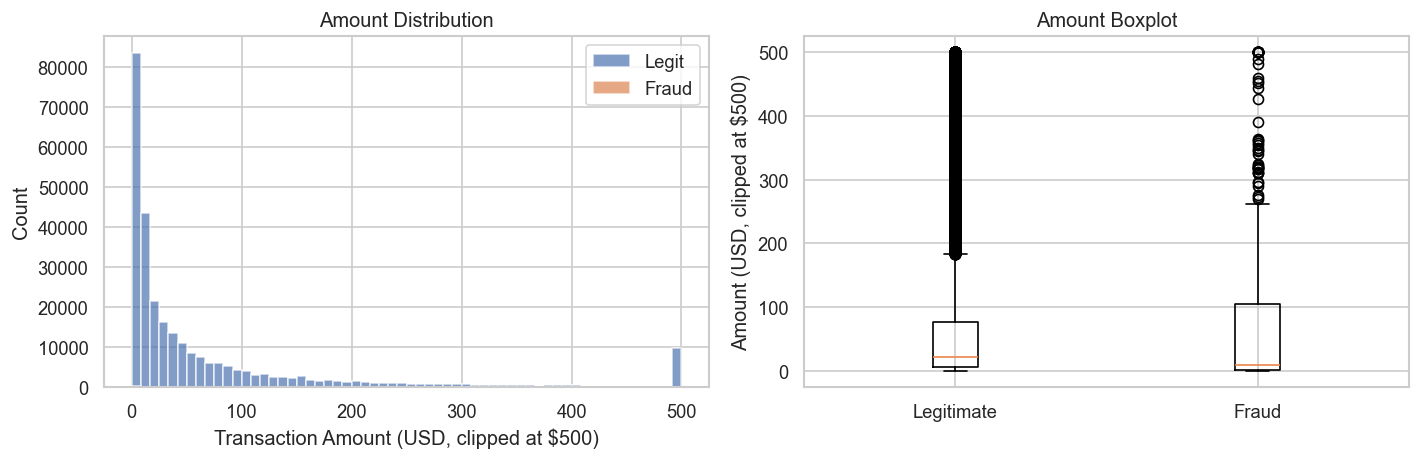

In [3]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print('Amount statistics:')
print(df.groupby('Class')['Amount'].describe().round(2))

print(f'\nAverage fraud amount:  ${fraud["Amount"].mean():.2f}')
print(f'Average legit amount:  ${legit["Amount"].mean():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(legit['Amount'].clip(upper=500), bins=60, color='#4C72B0', alpha=0.7, label='Legit')
axes[0].hist(fraud['Amount'].clip(upper=500), bins=60, color='#DD8452', alpha=0.7, label='Fraud')
axes[0].set_xlabel('Transaction Amount (USD, clipped at $500)')
axes[0].set_ylabel('Count')
axes[0].set_title('Amount Distribution')
axes[0].legend()

axes[1].boxplot(
    [legit['Amount'].clip(upper=500), fraud['Amount'].clip(upper=500)],
    labels=['Legitimate', 'Fraud']
)
axes[1].set_ylabel('Amount (USD, clipped at $500)')
axes[1].set_title('Amount Boxplot')
plt.tight_layout()
plt.show()

## 3. Time Distribution

Do frauds happen at different times of day?

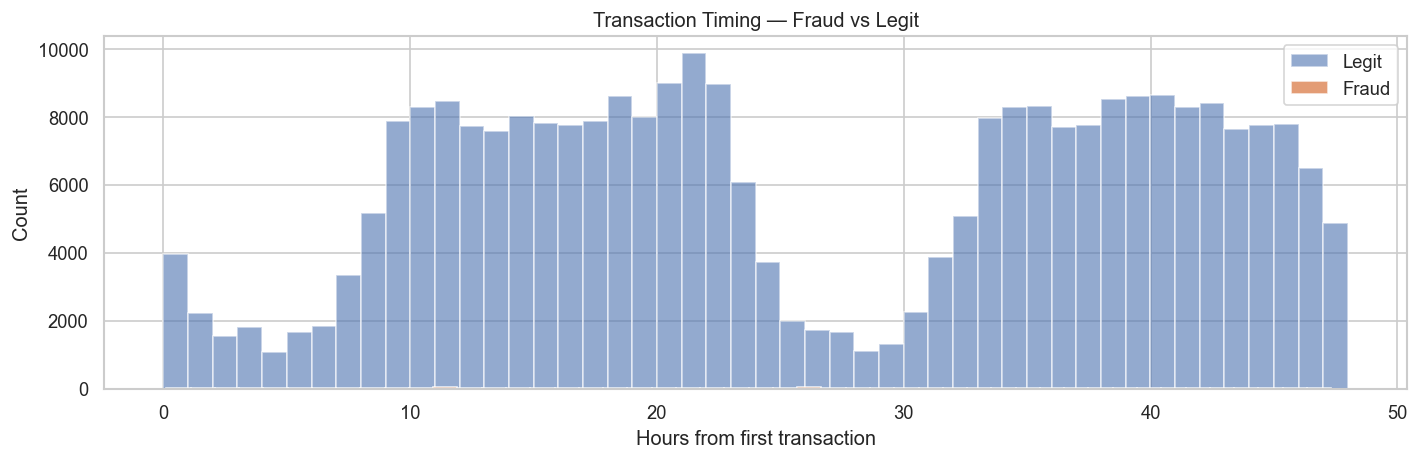

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(legit['Time'] / 3600, bins=48, alpha=0.6, label='Legit', color='#4C72B0')
ax.hist(fraud['Time'] / 3600, bins=48, alpha=0.8, label='Fraud', color='#DD8452')
ax.set_xlabel('Hours from first transaction')
ax.set_ylabel('Count')
ax.set_title('Transaction Timing — Fraud vs Legit')
ax.legend()
plt.tight_layout()
plt.show()

fraud transactions are slightly more concentrated in low-activity periods

(night hours), but the signal is weak (Time alone is not a strong predictor)

## 4. PCA Features: Which Separate Fraud Best?

V1-V28 are PCA components, we can't interpret them directly, but we can see which ones
have the most different distributions between classes. Those will be important to the model.

Top 10 most separating PCA features (by median difference):
Class    diff
V14    6.7817
V12    5.6442
V3     5.2574
V17    5.2381
V10    4.4870
V4     4.1996
V11    3.6211
V16    3.6172
V7     3.0755
V2     2.6538


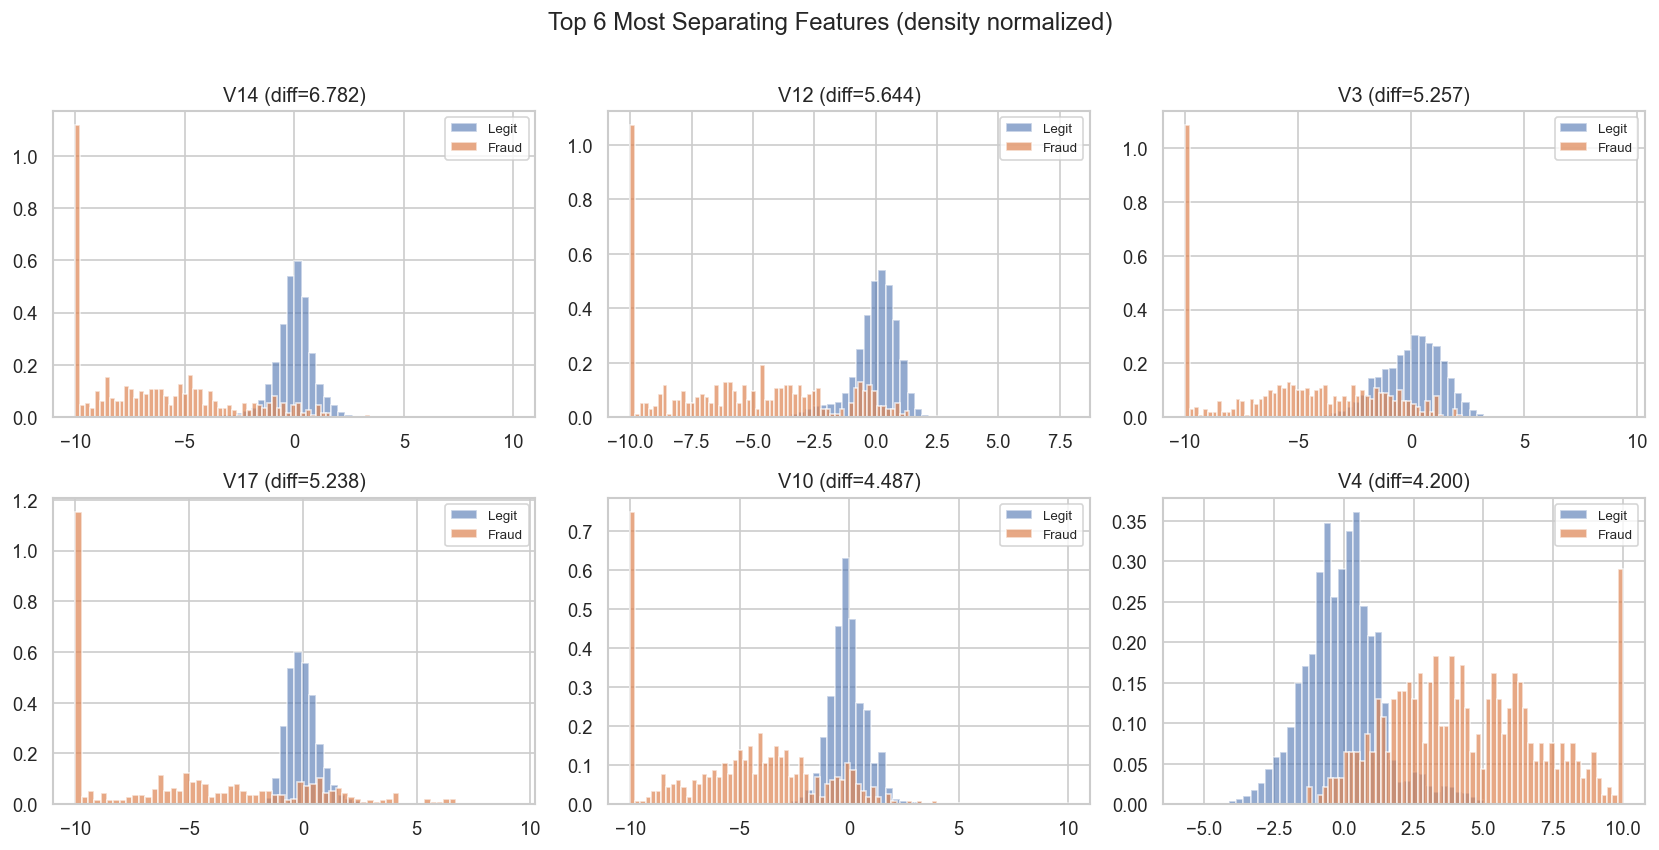

In [5]:
v_cols = [f'V{i}' for i in range(1, 29)]

# Compute difference in medians as a quick proxy for separability
median_diffs = (
    df.groupby('Class')[v_cols].median()
    .T
    .assign(diff=lambda x: (x[1] - x[0]).abs())
    .sort_values('diff', ascending=False)
)

print('Top 10 most separating PCA features (by median difference):')
print(median_diffs[['diff']].head(10).round(4))

# Plot top 6
top_features = median_diffs.index[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].hist(legit[feat].clip(-10, 10), bins=60, alpha=0.6, 
                 label='Legit', color='#4C72B0', density=True)
    axes[i].hist(fraud[feat].clip(-10, 10), bins=60, alpha=0.7, 
                 label='Fraud', color='#DD8452', density=True)
    axes[i].set_title(f'{feat} (diff={median_diffs.loc[feat, "diff"]:.3f})')
    axes[i].legend(fontsize=8)

plt.suptitle('Top 6 Most Separating Features (density normalized)', y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation with Target

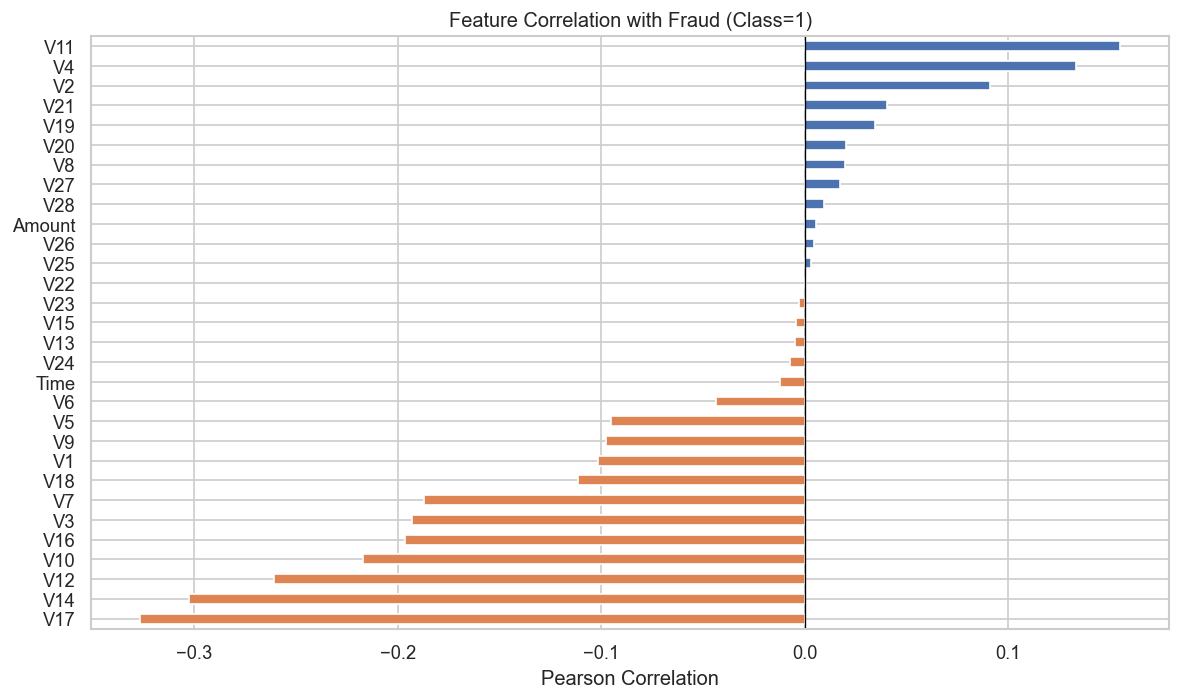

In [9]:
correlations = df[v_cols + ['Amount', 'Time']].corrwith(df['Class']).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DD8452' if v < 0 else '#4C72B0' for v in correlations]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Fraud (Class=1)')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

V17, V14, V12 have strong negative correlation with fraud

V4, V11 have positive correlation. These will likely be important features

## 6. Missing Values & Data Quality

In [10]:
missing = df.isnull().sum()
print(f'Missing values: {missing.sum()} (dataset is clean, no imputation needed)')
print(f'Negative amounts: {(df["Amount"] < 0).sum()} (none — good)')
print(f'Duplicate rows: {df.duplicated().sum()}')

Missing values: 0 (dataset is clean, no imputation needed)
Negative amounts: 0 (none — good)
Duplicate rows: 1081


## EDA Summary
492 frauds in 284,807 transactions (0.17%) — extreme imbalance

Average fraud amount: $122.21 — meaningful dollar value at stake

V4, V11, V14, V17 are likely the most important model features

No missing data — dataset is clean

Only Time and Amount need scaling — V1-V28 are already PCA-normalized
